<div style="color: #0B39C9; font-size: 24px; font-weight: 700;">

DỰ ÁN: XÂY DỰNG MÔ HÌNH PHÂN LOẠI VÀ DỰ BÁO RỦI RO KHÁCH HÀNG VAY VỐN

</div>

# <span style="color: #E60000;">Notebook 06.1. Threshold Optimization</span>

*Tối ưu ngưỡng dự đoán cho HistGradientBoosting bằng tập Validation trước khi đánh giá cuối cùng trên tập Test*

---
**Input:** Bảng `application_features` trong PostgreSQL và cấu hình HistGradientBoosting đã chốt tại Notebook 06.

**Output:** Mô hình HistGradientBoosting, ngưỡng dự đoán được chọn từ Validation và bộ metric đánh giá cuối cùng trên Test.

**Pipeline:** Feature Engineering → Machine Learning → **Threshold Optimization** → FastAPI & Streamlit


## I. Giới thiệu


### 1. Mục tiêu của Notebook 06.1


Notebook này tìm ngưỡng dự đoán phù hợp cho HistGradientBoosting theo định hướng ưu tiên phát hiện khách hàng có nguy cơ nợ xấu. Vì chi phí bỏ sót khách hàng rủi ro được xem là nghiêm trọng hơn cảnh báo nhầm khách hàng tốt, ngưỡng được lựa chọn trên tập Validation bằng F2-score, sau đó đánh giá một lần trên tập Test.


### 2. Vai trò của ngưỡng dự đoán


Ngưỡng `0,5` chỉ là giá trị mặc định để chuyển xác suất thành nhãn dự đoán. Khi giảm ngưỡng, mô hình thường phát hiện được nhiều khách hàng nợ xấu hơn nên Recall tăng, nhưng số cảnh báo nhầm cũng có thể tăng. Ngược lại, tăng ngưỡng thường làm Precision tăng nhưng có nguy cơ bỏ sót nhiều khách hàng nợ xấu hơn.

Trong bài toán tín dụng của dự án, nhóm ưu tiên hạn chế **False Negative (FN)**, tức trường hợp khách hàng thực tế có nguy cơ nợ xấu nhưng mô hình lại dự đoán là trả được nợ. Vì vậy, F2-score được sử dụng làm tiêu chí chính để lựa chọn ngưỡng.

Công thức F2-score:

$$
F_2 = \frac{(1 + 2^2)\times Precision \times Recall}
{2^2 \times Precision + Recall}
$$

hay tương đương:

$$
F_2 = \frac{5PR}{4P + R}
$$

Trong đó:

- $P$ là Precision.
- $R$ là Recall.
- F2-score đặt trọng số lớn hơn cho Recall so với Precision, phù hợp với mục tiêu ưu tiên phát hiện khách hàng có nguy cơ nợ xấu.

### 3. Mạch liên kết: Notebook 06 → Notebook 06.1 → FastAPI & Streamlit

Notebook 06 lựa chọn HistGradientBoosting; Notebook 06.1 lựa chọn ngưỡng dự đoán, đánh giá cuối cùng trên tập Test và lưu model package. Mô hình cùng metadata sau đó được sử dụng bởi FastAPI và Streamlit trong thư mục `app`.

## II. Đọc dữ liệu


### 1. Chuẩn bị thư viện và kết nối PostgreSQL


In [1]:
import os
import pandas as pd
import numpy as np

from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sklearn.model_selection import train_test_split

Đoạn code bên dưới import thư viện và tạo kết nối PostgreSQL từ file `.env`.


In [2]:
# Tìm file .env từ thư mục hiện tại hoặc thư mục cha.
env_path = Path.cwd() / ".env"
if not env_path.exists():
    env_path = Path.cwd().parent / ".env"
if not env_path.exists():
    raise FileNotFoundError("Không tìm thấy file .env.")

load_dotenv(env_path)
db_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER", "postgres"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST", "localhost"),
    port=int(os.getenv("DB_PORT", "5432")),
    database=os.getenv("DB_NAME", "credit_risk_db"),
)
engine = create_engine(db_url)


### 2. Đọc bảng `application_features`


Đoạn code bên dưới đọc bảng `application_features` và hiển thị 5 dòng đầu.


In [3]:
# Đọc dữ liệu đã tạo tại Notebook 05.
df = pd.read_sql("SELECT * FROM public.application_features", engine)

assert {"sk_id_curr", "target"}.issubset(df.columns), (
    "Dữ liệu phải có sk_id_curr và target."
)

print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng × {df.shape[1]:,} cột")
display(df.head())


Kích thước dữ liệu: 306,195 dòng × 234 cột


,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,credit_card_balance_to_income,has_pos_cash_dpd,pos_cash_history_months,age_income_interaction,late_debt_interaction,ext_ltv_interaction,ext_credit_income_interaction,ext_dti_interaction,ext_min_ltv_interaction,ext_bureau_debt_interaction
0,112760,0,Cash loans,F,N,Y,0.0,135000.0,450000.0,24543.0,...,NaN,0,11.0,35-44 | Thấp,Không ghi nhận trễ | Thấp,0.705723,2.352409,0.128300,0.978805,0.175144
1,112761,0,Revolving loans,M,N,Y,0.0,193500.0,450000.0,22500.0,...,NaN,0,12.0,35-44 | Cao,Không ghi nhận trễ | Trung bình,0.450933,1.048681,0.052434,0.497122,0.119399
2,112762,0,Cash loans,F,N,Y,0.0,225000.0,781920.0,40486.5,...,NaN,0,NaN,25-34 | Cao,Không ghi nhận trễ | Cao,0.512698,1.538094,0.079640,0.677262,0.065402
3,112763,0,Cash loans,F,N,Y,0.0,72000.0,545040.0,20677.5,...,NaN,0,7.0,55+ | Rất thấp,Không ghi nhận trễ | Thấp,0.568609,3.553809,0.134823,0.671736,0.234200
4,112764,0,Cash loans,F,Y,Y,0.0,225000.0,742500.0,69421.5,...,NaN,0,5.0,55+ | Cao,NaN,0.374557,1.236037,0.115566,0.494002,NaN


### 3. Kiểm tra dữ liệu đầu vào


Đoạn code bên dưới tóm tắt quy mô, missing và phân bố target của dữ liệu đầu vào.


In [4]:
# Tạo bảng kiểm tra ngắn gọn.
input_summary = pd.DataFrame({
    "Chỉ tiêu": [
        "Số dòng", "Số cột", "Số khách hàng",
        "Số dòng trùng", "Tổng giá trị thiếu",
        "Tỷ lệ thiếu (%)", "Tỷ lệ target = 1 (%)",
    ],
    "Kết quả": [
        f"{len(df):,}",
        f"{df.shape[1]:,}",
        f"{df['sk_id_curr'].nunique():,}",
        f"{df.duplicated().sum():,}",
        f"{df.isna().sum().sum():,}",
        f"{df.isna().sum().sum() / df.size * 100:.2f}",
        f"{df['target'].mean() * 100:.2f}",
    ],
})

display(input_summary)


,Chỉ tiêu,Kết quả
0,Số dòng,"306,195"
1,Số cột,234
2,Số khách hàng,"306,195"
3,Số dòng trùng,0
4,Tổng giá trị thiếu,"4,609,044"
5,Tỷ lệ thiếu (%),6.43
6,Tỷ lệ target = 1 (%),8.09


### 4. Xác định Feature và Target


Đoạn code bên dưới tạo Feature và Target, đồng thời loại hai interaction cần tạo lại từ Train.


In [5]:
ID_COLUMN = "sk_id_curr"
TARGET_COLUMN = "target"

# Tách Feature và Target.
X = df.drop(columns=[ID_COLUMN, TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()

# Hai interaction dùng phân vị sẽ được tạo lại từ Train.
INTERACTION_HOC_LAI = [
    "age_income_interaction",
    "late_debt_interaction",
]
interaction_co_san = [col for col in INTERACTION_HOC_LAI if col in X.columns]
X = X.drop(columns=interaction_co_san)

assert ID_COLUMN not in X.columns
assert TARGET_COLUMN not in X.columns
assert len(X) == len(y)

print(f"Số Feature ban đầu: {X.shape[1]:,}")
print("Interaction sẽ tạo lại:", interaction_co_san)


Số Feature ban đầu: 230
Interaction sẽ tạo lại: ['age_income_interaction', 'late_debt_interaction']


## III. Chia tập Train, Validation và Test


### 1. Tách tập Test


Đoạn code bên dưới giữ riêng 20% dữ liệu làm tập Test.


In [6]:
# Tách Test trước để không dùng khi chọn ngưỡng.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


### 2. Tách tập Train và Validation


Đoạn code bên dưới chia phần còn lại thành Train và Validation.


In [7]:
# Validation chiếm 20% của phần Train + Validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_train_val,
)


### 3. Kiểm tra phân bố Target


Đoạn code bên dưới kiểm tra quy mô và tỷ lệ nợ xấu của ba tập dữ liệu.


In [8]:
# Kiểm tra ba tập không trùng nhau và giữ cùng danh sách cột.
assert len(X_train) + len(X_val) + len(X_test) == len(X)
assert X_train.index.intersection(X_val.index).empty
assert X_train.index.intersection(X_test.index).empty
assert X_val.index.intersection(X_test.index).empty
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns)

# Tóm tắt kết quả chia dữ liệu.
split_summary = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Validation", "Test"],
    "Số dòng": [len(X_train), len(X_val), len(X_test)],
    "Tỷ trọng (%)": [
        len(X_train) / len(X) * 100,
        len(X_val) / len(X) * 100,
        len(X_test) / len(X) * 100,
    ],
    "Tỷ lệ target = 1 (%)": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100,
    ],
})

display(split_summary.round(2))


,Tập dữ liệu,Số dòng,Tỷ trọng (%),Tỷ lệ target = 1 (%)
0,Train,195964,64.0,8.09
1,Validation,48992,16.0,8.09
2,Test,61239,20.0,8.09


### 4. Loại cột không cung cấp thông tin

Đoạn code bên dưới xác định các cột hằng số chỉ từ tập Train, sau đó loại cùng danh sách cột khỏi Train, Validation và Test để đồng bộ với preprocessing của Notebook 06.

In [9]:
# Chỉ dùng Train để xác định các cột hằng số.
constant_cols = [
    col
    for col in X_train.columns
    if X_train[col].nunique(dropna=False) <= 1
]

# Áp dụng cùng danh sách cho cả ba tập.
X_train = X_train.drop(columns=constant_cols)
X_val = X_val.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

# Kiểm tra cấu trúc feature còn đồng nhất.
assert list(X_train.columns) == list(X_val.columns)
assert list(X_train.columns) == list(X_test.columns)

print(f"Số cột hằng số đã loại: {len(constant_cols)}")
print("Danh sách:", constant_cols)

Số cột hằng số đã loại: 1
Danh sách: ['flag_mobil']


### 5. Tạo lại Interaction Features từ tập Train

In [10]:
# Hai interaction dùng ngưỡng phân vị phải được học lại từ tập Train
# để tránh sử dụng thông tin của Validation/Test.

TUOI_BINS = [0, 25, 35, 45, 55, np.inf]
TUOI_LABELS = ["<25", "25-34", "35-44", "45-54", "55+"]

NHAN_THU_NHAP = [
    "Rất thấp",
    "Thấp",
    "Trung bình",
    "Cao",
    "Rất cao",
]

NHAN_DU_NO = [
    "Thấp",
    "Trung bình",
    "Cao",
    "Rất cao",
]

TRE_HAN_COLS = [
    "bureau_max_overdue",
    "installments_max_late",
    "pos_cash_max_dpd",
]

NHAN_THIEU = "Không rõ"

In [11]:
def hoc_nguong(cot, so_nhom):
    """Học các ngưỡng phân vị chỉ từ tập Train."""
    _, moc = pd.qcut(
        cot.dropna(),
        q=so_nhom,
        retbins=True,
        duplicates="drop",
    )

    moc[0] = -np.inf
    moc[-1] = np.inf

    return moc


# Ngưỡng thu nhập học từ Train.
nguong_thu_nhap = hoc_nguong(
    X_train["amt_income_total"],
    5,
)

# Chỉ chia phân vị trên nhóm thực sự còn dư nợ.
co_du_no_train = X_train["bureau_sum_debt"] > 0

nguong_du_no = hoc_nguong(
    X_train.loc[co_du_no_train, "bureau_sum_debt"],
    4,
)

print(
    "Ngưỡng thu nhập:",
    [f"{moc:,.0f}" for moc in nguong_thu_nhap[1:-1]],
)

print(
    "Ngưỡng dư nợ:",
    [f"{moc:,.0f}" for moc in nguong_du_no[1:-1]],
)

Ngưỡng thu nhập: ['99,000', '135,000', '162,000', '225,000']
Ngưỡng dư nợ: ['139,916', '399,654', '992,387']


In [12]:
def tao_interaction(data):
    """Tạo lại hai interaction bằng ngưỡng đã học từ Train."""
    data = data.copy()

    # Ghép nhóm tuổi với nhóm thu nhập.
    nhom_tuoi = pd.cut(
        data["age_years"],
        TUOI_BINS,
        labels=TUOI_LABELS,
    )

    nhan_thu_nhap = NHAN_THU_NHAP[
        : len(nguong_thu_nhap) - 1
    ]

    nhom_thu_nhap = pd.cut(
        data["amt_income_total"],
        nguong_thu_nhap,
        labels=nhan_thu_nhap,
    )

    age_income = (
        nhom_tuoi.astype("string")
        + " | "
        + nhom_thu_nhap.astype("string")
    )

    data["age_income_interaction"] = (
        age_income.fillna(NHAN_THIEU)
    )

    # Xác định khách từng có trễ hạn.
    tung_tre = (
        data[TRE_HAN_COLS]
        .fillna(0)
        .gt(0)
        .any(axis=1)
    )

    nhom_tre = pd.Series(
        np.where(
            tung_tre,
            "Từng trễ",
            "Không ghi nhận trễ",
        ),
        index=data.index,
        dtype="string",
    )

    # Phân nhóm dư nợ.
    du_no = data["bureau_sum_debt"]

    nhom_du_no = pd.Series(
        NHAN_THIEU,
        index=data.index,
        dtype="string",
    )

    nhom_du_no.loc[
        du_no == 0
    ] = "Không còn dư nợ"

    co_du_no = du_no > 0

    nhan_du_no = NHAN_DU_NO[
        : len(nguong_du_no) - 1
    ]

    nhom_du_no.loc[co_du_no] = pd.cut(
        du_no.loc[co_du_no],
        nguong_du_no,
        labels=nhan_du_no,
    ).astype("string")

    data["late_debt_interaction"] = (
        nhom_tre
        + " | "
        + nhom_du_no
    )

    data.loc[
        data["has_bureau"].fillna(0) == 0,
        "late_debt_interaction",
    ] = NHAN_THIEU

    return data

In [13]:
X_train = tao_interaction(X_train)
X_val = tao_interaction(X_val)
X_test = tao_interaction(X_test)

interaction_summary = pd.DataFrame({
    "Interaction": INTERACTION_HOC_LAI,
    "Số nhóm Train": [
        X_train[col].nunique()
        for col in INTERACTION_HOC_LAI
    ],
    "Số nhóm Validation": [
        X_val[col].nunique()
        for col in INTERACTION_HOC_LAI
    ],
    "Số nhóm Test": [
        X_test[col].nunique()
        for col in INTERACTION_HOC_LAI
    ],
})

display(interaction_summary)

,Interaction,Số nhóm Train,Số nhóm Validation,Số nhóm Test
0,age_income_interaction,25,25,25
1,late_debt_interaction,13,13,13


In [14]:
assert "age_income_interaction" in X_train.columns
assert "late_debt_interaction" in X_train.columns

assert "age_income_interaction" in X_val.columns
assert "late_debt_interaction" in X_val.columns

assert "age_income_interaction" in X_test.columns
assert "late_debt_interaction" in X_test.columns

print("Đã tạo lại đầy đủ 2 interaction cho Train / Validation / Test.")

Đã tạo lại đầy đủ 2 interaction cho Train / Validation / Test.


**Nhận xét:**
- Hai feature age_income_interaction và late_debt_interaction không sử dụng phiên bản đã tạo trong NB05 vì các phiên bản đó được xây dựng từ phân vị của toàn bộ dữ liệu.
- Các ngưỡng thu nhập và dư nợ được học chỉ từ tập Train, sau đó áp dụng cố định cho Validation và Test.
- Cách xử lý này giúp giữ lại hai interaction được thiết kế ở NB05 nhưng không làm rò rỉ thông tin từ Validation hoặc Test vào quá trình tạo feature.

## IV. Chuẩn bị dữ liệu


### 1. Xác định cột số và cột phân loại


Đoạn code bên dưới xác định kiểu cột từ tập Train.


In [15]:
# Chỉ dùng Train để xác định kiểu cột.
num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(exclude="number").columns

In [16]:
print(f"Cột số: {len(num_cols):,}")
print(f"Cột phân loại: {len(cat_cols):,}")

print(
    "age_income_interaction thuộc categorical:",
    "age_income_interaction" in cat_cols
)

print(
    "late_debt_interaction thuộc categorical:",
    "late_debt_interaction" in cat_cols
)

Cột số: 212
Cột phân loại: 19
age_income_interaction thuộc categorical: True
late_debt_interaction thuộc categorical: True


### 2. Xử lý giá trị thiếu


Đoạn code bên dưới dùng median của Train cho cột số và nhãn `Unknown` cho cột phân loại.


In [17]:
# Các cột lịch sử có thể điền 0 khi khách không có dữ liệu lịch sử tương ứng.
COT_KHOI_LUONG = {
    "has_bureau": [
        "bureau_count",
        "bureau_sum_credit",
        "bureau_sum_debt",
        "bureau_max_overdue",
        "bureau_recent_loan_12m_count",
        "bureau_recent_12m_overdue_count",
        "bureau_balance_month_count",
        "bureau_balance_dpd_month_count",
        "bureau_balance_closed_month_count",
        "bureau_balance_unknown_month_count",
        "bureau_balance_delinquent_loan_count",
        "bureau_balance_max_dpd_status",
    ],

    "has_previous": [
        "previous_count",
        "previous_sum_credit",
        "previous_avg_credit",
        "previous_approved_count",
        "previous_refused_count",
        "previous_recent_12m_count",
        "previous_recent_12m_approved_count",
        "previous_recent_12m_refused_count",
        "previous_approved_sum_credit",
    ],

    "has_installments": [
        "installments_count",
        "installments_sum_due",
        "installments_sum_paid",
        "installments_avg_late",
        "installments_max_late",
        "installments_underpaid_count",
        "installments_underpaid_amount",
        "installments_recent_12m_late_count",
        "installments_recent_12m_count",
        "installments_recent_12m_underpaid_count",
        "installments_recent_12m_underpaid_amount",
    ],

    "has_pos_cash": [
        "pos_cash_count",
        "pos_cash_avg_dpd",
        "pos_cash_max_dpd",
        "pos_cash_contract_count",
        "pos_cash_recent_12m_dpd_count",
        "pos_cash_recent_12m_max_dpd",
    ],

    "has_credit_card": [
        "credit_card_count",
        "credit_card_avg_balance",
        "credit_card_max_balance",
        "credit_card_avg_limit",
        "credit_card_max_dpd",
        "credit_card_contract_count",
        "credit_card_avg_utilization",
        "credit_card_max_utilization",
        "credit_card_recent_12m_max_utilization",
    ],
}

# Chỉ giữ các cột thực sự tồn tại.
COT_KHOI_LUONG = {
    flag: [col for col in cols if col in X_train.columns]
    for flag, cols in COT_KHOI_LUONG.items()
    if flag in X_train.columns
}

In [18]:
def dien_0_lich_su(data):
    """Điền 0 cho các biến lịch sử khi khách không có lịch sử tương ứng."""
    data = data.copy()

    for flag, cols in COT_KHOI_LUONG.items():
        khong_co_lich_su = data[flag] == 0

        data.loc[khong_co_lich_su, cols] = (
            data.loc[khong_co_lich_su, cols]
            .fillna(0)
        )

    return data

Đoạn code bên dưới áp dụng quy tắc điền 0 cho các biến lịch sử khi khách hàng không có loại lịch sử tương ứng.

In [19]:
X_train = dien_0_lich_su(X_train)
X_val = dien_0_lich_su(X_val)
X_test = dien_0_lich_su(X_test)

print("Đã áp dụng quy tắc điền 0 theo lịch sử cho Train / Validation / Test.")

Đã áp dụng quy tắc điền 0 theo lịch sử cho Train / Validation / Test.


In [20]:
from sklearn.impute import SimpleImputer

# Imputer chỉ học từ tập Train.
num_imputer = SimpleImputer(
    strategy="median",
    keep_empty_features=True,
)

cat_imputer = SimpleImputer(
    strategy="constant",
    fill_value="Unknown",
)

Đoạn code bên dưới xử lý missing của các feature số. Median chỉ được học từ tập Train rồi áp dụng cho Validation và Test.

In [21]:
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(
        X_train[num_cols]
    ),
    columns=num_cols,
    index=X_train.index,
)

X_val_num = pd.DataFrame(
    num_imputer.transform(
        X_val[num_cols]
    ),
    columns=num_cols,
    index=X_val.index,
)

X_test_num = pd.DataFrame(
    num_imputer.transform(
        X_test[num_cols]
    ),
    columns=num_cols,
    index=X_test.index,
)

Đoạn code bên dưới chuẩn hóa định dạng các cột phân loại trước khi xử lý missing.

In [22]:
def chuan_hoa_cot_chu(data):
    """Đổi giá trị thiếu ở cột phân loại về dạng SimpleImputer hiểu được."""
    cot_chu = data[cat_cols].astype(object)
    return cot_chu.where(
        cot_chu.notna(),
        np.nan,
    )

Đoạn code bên dưới điền nhãn `Unknown` cho các feature phân loại thiếu. Quy tắc được học từ Train rồi áp dụng cho Validation và Test.

In [23]:
X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(
        chuan_hoa_cot_chu(X_train)
    ),
    columns=cat_cols,
    index=X_train.index,
)

X_val_cat = pd.DataFrame(
    cat_imputer.transform(
        chuan_hoa_cot_chu(X_val)
    ),
    columns=cat_cols,
    index=X_val.index,
)

X_test_cat = pd.DataFrame(
    cat_imputer.transform(
        chuan_hoa_cot_chu(X_test)
    ),
    columns=cat_cols,
    index=X_test.index,
)

In [24]:
assert not X_train_num.isna().any().any()
assert not X_val_num.isna().any().any()
assert not X_test_num.isna().any().any()

assert not X_train_cat.isna().any().any()
assert not X_val_cat.isna().any().any()
assert not X_test_cat.isna().any().any()

print("Không còn missing sau xử lý.")

Không còn missing sau xử lý.


Các biến lịch sử được điền 0 khi khách hàng không có lịch sử tương ứng, nhằm giữ đúng ý nghĩa nghiệp vụ. Phần missing còn lại của biến số được điền bằng median chỉ tính từ tập Train; biến phân loại thiếu được gán nhãn Unknown. Cùng quy tắc được áp dụng cho Validation và Test để hạn chế Data Leakage.

### 3. Mã hóa và kiểm tra dữ liệu


Đoạn code bên dưới học các nhóm phân loại từ Train bằng `OneHotEncoder`.

In [25]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

encoder.fit(X_train_cat)

encoded_cols = encoder.get_feature_names_out(
    cat_cols
)

Đoạn code bên dưới định nghĩa hàm ghép feature số với các feature phân loại đã one-hot encoding.

In [26]:
def build_matrix(data_num, data_cat, index):
    """Ghép feature số với feature phân loại đã mã hóa."""
    encoded = pd.DataFrame(
        encoder.transform(data_cat),
        columns=encoded_cols,
        index=index,
    )

    return pd.concat(
        [data_num, encoded],
        axis=1,
    )

Đoạn code bên dưới tạo ma trận feature cuối cho Train, Validation và Test.

In [27]:
X_train_hgb = build_matrix(
    X_train_num,
    X_train_cat,
    X_train.index,
)

X_val_hgb = build_matrix(
    X_val_num,
    X_val_cat,
    X_val.index,
)

X_test_hgb = build_matrix(
    X_test_num,
    X_test_cat,
    X_test.index,
)

FEATURE_NAMES = X_train_hgb.columns.tolist()

Đoạn code bên dưới kiểm tra ba tập có cùng cấu trúc feature và không còn missing hoặc giá trị vô cực.

In [28]:
assert list(X_val_hgb.columns) == FEATURE_NAMES
assert list(X_test_hgb.columns) == FEATURE_NAMES

assert not X_train_hgb.columns.duplicated().any()

for data in [
    X_train_hgb,
    X_val_hgb,
    X_test_hgb,
]:
    assert data.select_dtypes(
        exclude="number"
    ).empty

    assert not data.isna().any().any()
    assert np.isfinite(
        data.to_numpy()
    ).all()

final_summary = pd.DataFrame({
    "Tập dữ liệu": [
        "Train",
        "Validation",
        "Test",
    ],
    "Số dòng": [
        len(X_train_hgb),
        len(X_val_hgb),
        len(X_test_hgb),
    ],
    "Số feature": [
        X_train_hgb.shape[1],
        X_val_hgb.shape[1],
        X_test_hgb.shape[1],
    ],
})

display(final_summary)

,Tập dữ liệu,Số dòng,Số feature
0,Train,195964,397
1,Validation,48992,397
2,Test,61239,397


**Nhận xét:**

- HistGradientBoosting được huấn luyện trên tập Train và tạo xác suất nợ xấu cho tập Validation.
- Các xác suất này chưa được chuyển thành quyết định cuối cùng vì kết quả còn phụ thuộc vào ngưỡng phân loại.
- Năm dòng minh họa chỉ giúp kiểm tra đầu ra của mô hình, không được dùng để kết luận chất lượng mô hình.
- Bước tiếp theo là đánh giá nhiều ngưỡng trên toàn bộ tập Validation và lựa chọn ngưỡng có F2-score cao nhất.

## V. Huấn luyện HistGradientBoosting


### 1. Cấu hình mô hình


In [29]:
import time
from sklearn.ensemble import HistGradientBoostingClassifier

# Giữ cùng cấu hình mô hình đã chọn ở Notebook 06.
hgb_model = HistGradientBoostingClassifier(
    max_iter=200, learning_rate=0.1, max_leaf_nodes=31,
    min_samples_leaf=50, class_weight="balanced", random_state=42,
)


### 2. Lựa chọn Feature đầu vào


In [30]:
# Sử dụng toàn bộ feature đã xử lý ở Mục IV.
model_features = FEATURE_NAMES

assert list(X_train_hgb.columns) == model_features
print(f"Số feature đưa vào mô hình: {len(model_features):,}")


Số feature đưa vào mô hình: 397


### 3. Huấn luyện mô hình trên tập Train


In [31]:
# Huấn luyện mô hình và đo thời gian thực hiện.
start_time = time.time()
hgb_model.fit(X_train_hgb, y_train)
training_time = time.time() - start_time

print(f"Thời gian huấn luyện: {training_time:.1f} giây")
print(f"Số vòng đã thực hiện: {hgb_model.n_iter_:,}")


Thời gian huấn luyện: 15.1 giây
Số vòng đã thực hiện: 104


### 4. Dự đoán xác suất trên tập Validation


In [32]:
# Lấy xác suất khách hàng thuộc nhóm nợ xấu (target = 1).
validation_probabilities = hgb_model.predict_proba(X_val_hgb)[:, 1]

# Kiểm tra số lượng và khoảng giá trị xác suất.
assert len(validation_probabilities) == len(y_val)
assert np.all((validation_probabilities >= 0) & (validation_probabilities <= 1))

validation_preview = pd.DataFrame({
    "Nhãn thực tế": y_val.iloc[:5].to_numpy(),
    "Xác suất nợ xấu": validation_probabilities[:5],
})
display(validation_preview.round(4))


,Nhãn thực tế,Xác suất nợ xấu
0,0,0.6856
1,0,0.2132
2,1,0.8613
3,0,0.4271
4,0,0.6721


**Nhận xét:**
- HistGradientBoosting được huấn luyện trên toàn bộ feature sau tiền xử lý của tập Train. Mô hình dừng trước giới hạn max_iter=200, cho thấy quá trình huấn luyện đã hoàn tất theo cơ chế dừng của thuật toán.
- Mô hình đã tạo được xác suất nợ xấu cho tập Validation. Chẳng hạn, khách hàng có nhãn thực tế 1 được dự đoán xác suất nợ xấu 0,8831.
- Một số khách hàng thực tế thuộc lớp 0 vẫn có xác suất nợ xấu cao. Điều này cho thấy mô hình có thể dự đoán nhầm, tùy thuộc ngưỡng được lựa chọn.
- Năm dòng minh họa chưa đủ để kết luận chất lượng mô hình. Bước tiếp theo là đánh giá toàn bộ tập Validation và tìm ngưỡng giúp F1-score cao nhất.

## VI. Tìm ngưỡng trên tập Validation


### 1. Thiết lập danh sách ngưỡng


In [33]:
# Thử các ngưỡng từ 0,05 đến 0,95.
thresholds = np.arange(0.05, 0.96, 0.01)

print(f"Số ngưỡng được thử: {len(thresholds)}")


Số ngưỡng được thử: 91


**Nhận xét:**

- Có 91 ngưỡng được thử, từ `0,05` đến `0,95` và cách nhau `0,01`.
- Ngưỡng là mức xác suất dùng để đổi kết quả thành nhãn: xác suất từ ngưỡng trở lên được dự đoán là nợ xấu `(1)`, ngược lại là trả được nợ `(0)`.
- Ngưỡng thấp thường phát hiện được nhiều khách nợ xấu hơn; ngưỡng cao thường giảm số khách bị cảnh báo nhầm.


### 2. Tính Precision, Recall, F1-score và F2-score 


In [34]:
from sklearn.metrics import (
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
)

# Tính Precision, Recall, F1-score và F2-score tại từng ngưỡng.
threshold_results = []

for threshold in thresholds:
    predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Ngưỡng": threshold,
        "Precision": precision_score(
            y_val,
            predictions,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_val,
            predictions,
            zero_division=0,
        ),
        "F1-score": f1_score(
            y_val,
            predictions,
            zero_division=0,
        ),
        "F2-score": fbeta_score(
            y_val,
            predictions,
            beta=2,
            zero_division=0,
        ),
    })

threshold_table = pd.DataFrame(threshold_results)
display(
    threshold_table.head()
)


,Ngưỡng,Precision,Recall,F1-score,F2-score
0,0.05,0.081208,0.999748,0.150215,0.306467
1,0.06,0.081584,0.999495,0.150855,0.307517
2,0.07,0.082188,0.998991,0.151881,0.309191
3,0.08,0.082990,0.997477,0.153232,0.311338
4,0.09,0.083982,0.996215,0.154906,0.314021


**Nhận xét:**

- Tại mỗi ngưỡng, xác suất được chuyển thành nhãn dự đoán và so sánh với nhãn thực tế của tập Validation.
- Precision phản ánh mức chính xác của các cảnh báo nợ xấu, Recall phản ánh khả năng phát hiện khách hàng nợ xấu thực tế.
- F1-score được giữ lại để tham khảo, trong khi F2-score là tiêu chí chính để lựa chọn ngưỡng vì đặt trọng số cao hơn cho Recall.


### 3. Chọn ngưỡng có F2-score cao nhất

In [35]:
# Chọn dòng có F2-score cao nhất.
best_threshold_row = threshold_table.loc[
    threshold_table["F2-score"].idxmax()
]

best_threshold = float(
    best_threshold_row["Ngưỡng"]
)

display(
    best_threshold_row.to_frame().T.round(4)
)


,Ngưỡng,Precision,Recall,F1-score,F2-score
44,0.49,0.1795,0.6906,0.285,0.4401


**Nhận xét:**

- Ngưỡng cuối được chọn là ngưỡng có F2-score cao nhất trên tập Validation.
- Tiêu chí này ưu tiên Recall hơn Precision, phù hợp với mục tiêu hạn chế bỏ sót khách hàng có nguy cơ nợ xấu.
- Tập Test không tham gia vào quá trình lựa chọn ngưỡng và chỉ được sử dụng ở bước đánh giá cuối cùng.


## VII. Trực quan hóa kết quả lựa chọn ngưỡng


### 1. Bảng các ngưỡng có F2-score cao nhất

In [50]:
# Lấy 10 ngưỡng có F2-score cao nhất.
top_thresholds = threshold_table.nlargest(
    10,
    "F2-score"
).reset_index(drop=True)

top_thresholds

,Ngưỡng,Precision,Recall,F1-score,F2-score
0,0.49,0.179546,0.690638,0.285000,0.440089
1,0.50,0.182879,0.676508,0.287924,0.439335
2,0.53,0.193996,0.642443,0.298004,0.439329
3,0.48,0.175652,0.700479,0.280872,0.438463
4,0.51,0.185982,0.662882,0.290469,0.438169
5,0.54,0.197557,0.628564,0.300628,0.437616
6,0.47,0.172391,0.710573,0.277466,0.437444
7,0.52,0.188985,0.650265,0.292858,0.436957
8,0.45,0.166781,0.734292,0.271823,0.436937
9,0.46,0.169262,0.721423,0.274192,0.436582


### 2. Biểu đồ Precision, Recall và F1-score theo ngưỡng


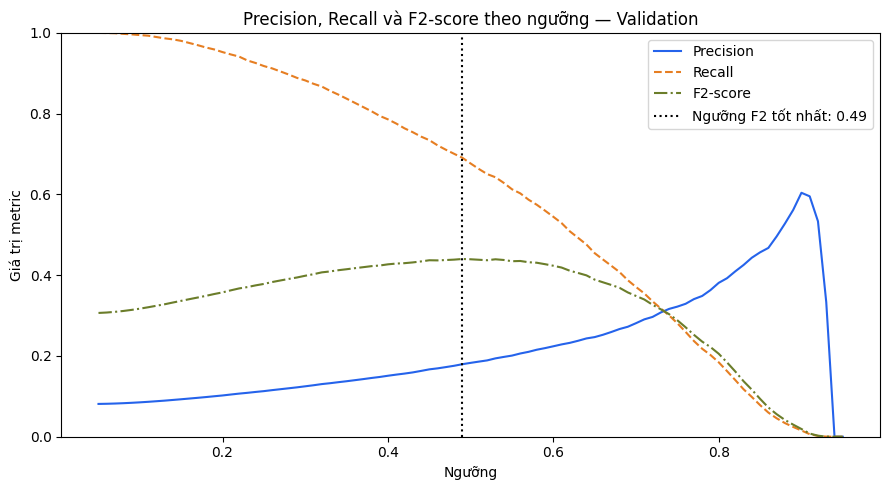

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt

# Vẽ Precision, Recall và F2-score theo ngưỡng trên tập Validation.
ax = threshold_table.plot(
    x="Ngưỡng",
    y=["Precision", "Recall", "F2-score"],
    style=["-", "--", "-."],
    color=["#2563EB", "#E67E22", "#6B7D2A"],
    figsize=(9, 5),
)

# Đánh dấu ngưỡng có F2-score cao nhất.
ax.axvline(
    best_threshold,
    color="black",
    linestyle=":",
    label=f"Ngưỡng F2 tốt nhất: {best_threshold:.2f}",
)

ax.set(
    title="Precision, Recall và F2-score theo ngưỡng — Validation",
    xlabel="Ngưỡng",
    ylabel="Giá trị metric",
    ylim=(0, 1),
)

plt.legend()
plt.tight_layout()
plt.show()

## VIII. Đánh giá cuối cùng trên tập Test


### 1. Đánh giá tại ngưỡng 0,5


In [38]:
# Lấy xác suất nợ xấu trên tập Test.
test_probabilities = hgb_model.predict_proba(
    X_test_hgb
)[:, 1]

assert len(test_probabilities) == len(y_test)
assert np.all(
    (test_probabilities >= 0)
    & (test_probabilities <= 1)
)

Đoạn code bên dưới tính ROC-AUC và PR-AUC trên tập Test. Hai metric này sử dụng xác suất dự đoán nên không phụ thuộc vào ngưỡng phân loại.

In [39]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities,
)

test_pr_auc = average_precision_score(
    y_test,
    test_probabilities,
)

display(
    pd.DataFrame(
        [{
            "ROC-AUC": test_roc_auc,
            "PR-AUC": test_pr_auc,
        }],
        index=["HistGradientBoosting - Test"],
    ).round(4)
)

,ROC-AUC,PR-AUC
HistGradientBoosting - Test,0.7757,0.2706


Đoạn code bên dưới chuyển xác suất trên tập Test thành nhãn dự đoán tại ngưỡng mặc định `0,5` để làm mốc tham chiếu.

In [40]:
test_predictions_05 = (
    test_probabilities >= 0.5
).astype(int)

assert len(test_predictions_05) == len(y_test)
metrics_05 = {
    "Ngưỡng": 0.5,
    "Precision": precision_score(
        y_test,
        test_predictions_05,
    ),
    "Recall": recall_score(
        y_test,
        test_predictions_05,
    ),
    "F1-score": f1_score(
        y_test,
        test_predictions_05,
    ),
    "F2-score": fbeta_score(
        y_test,
        test_predictions_05,
        beta=2,
    ),
}
display(pd.DataFrame([metrics_05]).round(4))


,Ngưỡng,Precision,Recall,F1-score,F2-score
0,0.5,0.1827,0.6829,0.2883,0.4413


**Nhận xét:**

- Kết quả tại ngưỡng mặc định `0,5` được giữ làm mốc tham chiếu.
- Precision, Recall, F1-score và F2-score tại ngưỡng này sẽ được so sánh với kết quả tại ngưỡng được lựa chọn từ Validation.

### 2. Đánh giá tại ngưỡng được chọn từ Validation


In [41]:
# Dùng ngưỡng đã chọn từ Validation.
test_predictions_best = (test_probabilities >= best_threshold).astype(int)

metrics_best = {
    "Ngưỡng": best_threshold,
    "Precision": precision_score(
        y_test,
        test_predictions_best,
    ),
    "Recall": recall_score(
        y_test,
        test_predictions_best,
    ),
    "F1-score": f1_score(
        y_test,
        test_predictions_best,
    ),
    "F2-score": fbeta_score(
        y_test,
        test_predictions_best,
        beta=2,
    ),
}
display(pd.DataFrame([metrics_best]).round(4))


,Ngưỡng,Precision,Recall,F1-score,F2-score
0,0.49,0.1793,0.6964,0.2852,0.4417


**Nhận xét:**

- Ngưỡng được sử dụng ở bước này được lựa chọn hoàn toàn từ tập Validation bằng F2-score.
- Tập Test chỉ được sử dụng để đánh giá khả năng tổng quát hóa của mô hình sau khi ngưỡng đã được cố định.

### 3. So sánh hai ngưỡng


In [42]:
# Đặt hai kết quả cạnh nhau để so sánh.
threshold_comparison = pd.DataFrame(
    [metrics_05, metrics_best],
    index=["Ngưỡng 0,5", "Ngưỡng được chọn"],
)
display(threshold_comparison.round(4))


,Ngưỡng,Precision,Recall,F1-score,F2-score
"Ngưỡng 0,5",0.50,0.1827,0.6829,0.2883,0.4413
Ngưỡng được chọn,0.49,0.1793,0.6964,0.2852,0.4417


**Nhận xét:**

- Bảng trên cho phép so sánh trực tiếp ngưỡng mặc định `0,5` với ngưỡng được lựa chọn từ Validation.
- Vì mục tiêu nghiệp vụ ưu tiên hạn chế False Negative, F2-score và Recall được chú trọng khi diễn giải kết quả; Precision được theo dõi để đánh giá mức cảnh báo nhầm.

### 4. Ma trận nhầm lẫn tại ngưỡng mới


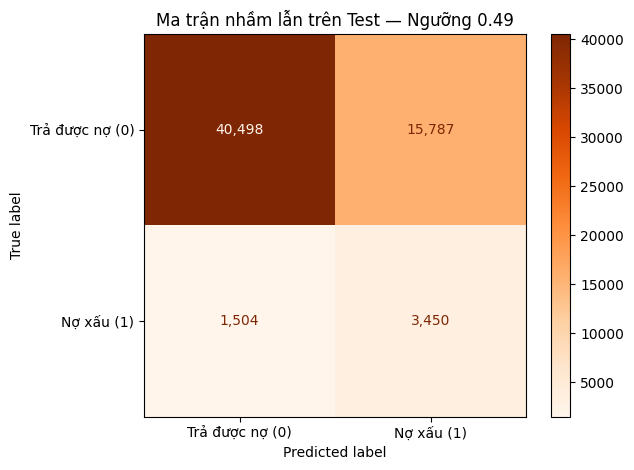

In [43]:
%matplotlib inline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Vẽ ma trận nhầm lẫn tại ngưỡng đã chọn.
test_confusion_matrix = confusion_matrix(y_test, test_predictions_best)
assert test_confusion_matrix.sum() == len(y_test)

ConfusionMatrixDisplay(
    test_confusion_matrix, display_labels=["Trả được nợ (0)", "Nợ xấu (1)"]
).plot(cmap="Oranges", values_format=",d")
plt.title(f"Ma trận nhầm lẫn trên Test — Ngưỡng {best_threshold:.2f}")
plt.tight_layout()
plt.show()


**Nhận xét:**

- Ma trận nhầm lẫn cho biết số khách hàng nợ xấu được phát hiện, số trường hợp bị bỏ sót và số khách hàng tốt bị cảnh báo nhầm tại ngưỡng cuối.
- Kết quả cụ thể được sử dụng để đánh giá mức đánh đổi giữa Recall và Precision trước khi đưa mô hình vào ứng dụng.

## IX. Lưu mô hình và kết quả


### 1. Lưu mô hình và thông tin tiền xử lý


In [44]:
import joblib

# Tạo gói gồm mô hình, ngưỡng và thông tin tiền xử lý.
model_package = {
    # Mô hình và threshold cuối.
    "model": hgb_model,
    "decision_threshold": best_threshold,
    "feature_names": FEATURE_NAMES,

    # Cấu trúc preprocessing.
    "constant_columns": constant_cols,
    "history_zero_fill_columns": COT_KHOI_LUONG,

    "numeric_columns": list(num_cols),
    "categorical_columns": list(cat_cols),

    "numeric_imputer": num_imputer,
    "categorical_imputer": cat_imputer,
    "encoder": encoder,

    # Interaction phải tái tạo khi inference.
    "interaction_features": INTERACTION_HOC_LAI,

    "income_bins": nguong_thu_nhap.tolist(),
    "debt_bins": nguong_du_no.tolist(),

    "age_bins": TUOI_BINS,
    "age_labels": TUOI_LABELS,
    "income_labels": NHAN_THU_NHAP,
    "debt_labels": NHAN_DU_NO,

    "late_payment_columns": TRE_HAN_COLS,
    "missing_label": NHAN_THIEU,
}


In [45]:
MODELS_DIR = env_path.parent / "models"
MODELS_DIR.mkdir(exist_ok=True)

model_path = MODELS_DIR / "hist_gradient_boosting_threshold_optimized.pkl"

joblib.dump(model_package, model_path)

print(f"Đã lưu mô hình: {model_path}")

Đã lưu mô hình: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\hist_gradient_boosting_threshold_optimized.pkl


In [46]:
loaded_package = joblib.load(model_path)

required_keys = {
    "model",
    "decision_threshold",
    "feature_names",

    "constant_columns",
    "history_zero_fill_columns",

    "numeric_columns",
    "categorical_columns",

    "numeric_imputer",
    "categorical_imputer",
    "encoder",

    "interaction_features",

    "income_bins",
    "debt_bins",

    "age_bins",
    "age_labels",
    "income_labels",
    "debt_labels",

    "late_payment_columns",
    "missing_label",
}

missing_keys = required_keys - set(loaded_package.keys())

assert not missing_keys, f"Model package thiếu metadata: {missing_keys}"
assert len(loaded_package["feature_names"]) == len(FEATURE_NAMES)

print("Model package có đầy đủ thông tin để tái tạo preprocessing.")

Model package có đầy đủ thông tin để tái tạo preprocessing.


### 2. Lưu ngưỡng và Metric


In [48]:
import json
from datetime import datetime

# Lưu thông tin chính của mô hình dưới dạng JSON.
final_metrics = {
    "model_name":
        "Credit Risk - HistGradientBoosting Threshold Optimized",

    "model_type":
        type(hgb_model).__name__,

    "model_version":
        "1.1.0",

    "trained_from":
        "06_1_threshold_optimization.ipynb",

    "saved_date":
        datetime.now().strftime(
            "%Y-%m-%d %H:%M"
        ),

    "features_count":
        len(FEATURE_NAMES),

    "threshold_metric":
        "F2-score",

    "decision_threshold":
        round(
            float(best_threshold),
            2,
        ),

    "validation_precision":
        round(
            float(best_threshold_row["Precision"]),
            4,
        ),

    "validation_recall":
        round(
            float(best_threshold_row["Recall"]),
            4,
        ),

    "validation_f1_score":
        round(
            float(best_threshold_row["F1-score"]),
            4,
        ),

    "validation_f2_score":
        round(
            float(best_threshold_row["F2-score"]),
            4,
        ),

    "test_roc_auc":
        round(
            float(test_roc_auc),
            4,
        ),

    "test_pr_auc":
        round(
            float(test_pr_auc),
            4,
        ),

    "test_precision":
        round(
            float(metrics_best["Precision"]),
            4,
        ),

    "test_recall":
        round(
            float(metrics_best["Recall"]),
            4,
        ),

    "test_f1_score":
        round(
            float(metrics_best["F1-score"]),
            4,
        ),

    "test_f2_score":
        round(
            float(metrics_best["F2-score"]),
            4,
        ),

    "confusion_matrix":
        test_confusion_matrix.tolist(),
}


metrics_path = MODELS_DIR / "hist_gradient_boosting_threshold_optimized_metrics.json"
metrics_path.write_text(json.dumps(final_metrics, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Đã lưu metric: {metrics_path}")


Đã lưu metric: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\hist_gradient_boosting_threshold_optimized_metrics.json


### 3. Kiểm tra file đã lưu


In [49]:
# Kiểm tra tên, trạng thái và dung lượng hai file mới.
saved_files = pd.DataFrame({
    "File": [model_path.name, metrics_path.name],
    "Tồn tại": [model_path.exists(), metrics_path.exists()],
    "Dung lượng (KB)": [model_path.stat().st_size / 1024, metrics_path.stat().st_size / 1024],
})

assert saved_files["Tồn tại"].all()
display(saved_files.round(1))


,File,Tồn tại,Dung lượng (KB)
0,hist_gradient_boosting_threshold_optimized.pkl,True,679.4
1,hist_gradient_boosting_threshold_optimized_met...,True,0.7


## X. Tổng kết


- Dữ liệu được chia theo tỷ lệ xấp xỉ `64% Train – 16% Validation – 20% Test`, cùng cách chia và preprocessing với Notebook 06.
- HistGradientBoosting được huấn luyện trên Train; các ngưỡng từ `0,05` đến `0,95` được đánh giá trên Validation.
- F2-score được sử dụng làm tiêu chí lựa chọn ngưỡng vì bài toán ưu tiên Recall và hạn chế False Negative.
- Sau khi ngưỡng được cố định từ Validation, tập Test được sử dụng để đánh giá cuối cùng một lần bằng ROC-AUC, PR-AUC, Precision, Recall, F1-score, F2-score và ma trận nhầm lẫn.
- Model package lưu cả mô hình, ngưỡng cuối và metadata/preprocessing cần thiết để FastAPI và Streamlit trong thư mục `app` có thể tái tạo đúng đầu vào của mô hình.